# 08 — Trade-offs entre qualidade e eficiência

Cruzamento entre acerto, foco, custo, tempo e chamadas.

In [1]:
# Configuração comum dos estudos integrados
from pathlib import Path
import re
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.22

ARTEFATOS = {
    'unificado': 'result_unificado_final.xlsx',
    'ferramenta': 'result_ferramenta_final.xlsx',
    'chats': 'result_chats_final.xlsx',
}

PASTAS_PROVAVEIS = [
    Path('../artefatos'),
    Path('../../artefatos'),
    Path('artefatos'),
    Path('../'),
    Path('.'),
    Path('/mnt/data'),
]

def encontra_arquivo(nome):
    for pasta in PASTAS_PROVAVEIS:
        caminho = pasta / nome
        if caminho.exists():
            return caminho.resolve()
    raise FileNotFoundError(
        f'Arquivo não encontrado: {nome}. Coloque os artefatos em ../artefatos/, artefatos/ ou na mesma pasta do notebook.'
    )

NOMES_MODELOS = {
    'claude-haiku-4-5': 'Claude Haiku',
    'claude-opus-4-7': 'Claude Opus',
    'claude-sonnet-4-6': 'Claude Sonnet',
    'deepseek-v4-flash': 'DeepSeek Flash',
    'deepseek-v4-pro': 'DeepSeek Pro',
    'gpt-4o-mini': 'GPT 4o mini',
    'gpt-5.4': 'GPT 5.4',
    'gpt-5.4-mini': 'GPT 5.4 mini',
    'gpt-5.5': 'GPT 5.5',
    'std_chatgpt': 'ChatGPT comercial',
    'std_claude': 'Claude comercial',
}

def provedor(modelo):
    m = str(modelo).lower()
    if 'claude' in m:
        return 'Anthropic'
    if 'gpt' in m or 'chatgpt' in m:
        return 'OpenAI'
    if 'deepseek' in m:
        return 'DeepSeek'
    return 'Outro'

def prepara(df, origem_padrao=None):
    """Cria campos de leitura do TCC em memória. Não salva nenhuma base intermediária."""
    df = df.copy()
    if 'origem_resultado' not in df.columns:
        df['origem_resultado'] = origem_padrao or 'nao_informada'
    for col in [
        'avaliacao_final', 'concisao_score', 'avaliacao_gpt', 'avaliacao_opus',
        'avaliacao_humana', 'resposta_tokens_tiktoken', 'input_tokens', 'output_tokens',
        'custo_estimado_usd', 'n_invocacoes', 'latencia_s'
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].replace('nao pertinente', np.nan), errors='coerce')
    if 'convergencia' in df.columns:
        df['convergencia'] = df['convergencia'].astype(bool)
    else:
        df['convergencia'] = np.nan
    df['acerto'] = df['avaliacao_final']
    df['resposta_direta'] = df['concisao_score']
    df['discordancia_avaliadores'] = ~df['convergencia']
    df['origem_legivel'] = df['origem_resultado'].map({
        'ferramenta': 'Ferramenta',
        'chat_comercial': 'Chat comercial'
    }).fillna(df['origem_resultado'])
    df['modelo_legivel'] = df['modelo'].map(NOMES_MODELOS).fillna(df['modelo'])
    df['provedor'] = df['modelo'].map(provedor)
    df['status_acerto'] = pd.cut(
        df['acerto'], bins=[-0.01, 0.01, 0.99, 1.01],
        labels=['Incorreta', 'Parcial', 'Correta']
    )
    df['acerto_total'] = (df['acerto'] == 1).astype(int)
    df['erro_total'] = (df['acerto'] == 0).astype(int)
    df['parcial'] = (df['acerto'] == 0.5).astype(int)
    df['nao_totalmente_correta'] = (df['acerto'] < 1).astype(int)
    return df

def ler_artefatos():
    caminhos = {k: encontra_arquivo(v) for k, v in ARTEFATOS.items()}
    df_unificado = prepara(pd.read_excel(caminhos['unificado']))
    df_ferramenta = prepara(pd.read_excel(caminhos['ferramenta']), 'ferramenta')
    df_chats = prepara(pd.read_excel(caminhos['chats']), 'chat_comercial')
    return caminhos, df_unificado, df_ferramenta, df_chats

caminhos, df, df_ferramenta, df_chats = ler_artefatos()
print('Artefatos lidos:')
for nome, caminho in caminhos.items():
    print(f'- {nome}: {caminho}')
print(f'Base unificada: {df.shape[0]} linhas x {df.shape[1]} colunas')

# Ordem padrão dos modelos: maior acerto médio primeiro.
ORDEM_MODELOS = (
    df.groupby('modelo_legivel')['acerto']
      .mean()
      .sort_values(ascending=False)
      .index
      .tolist()
)

def pct(x):
    if pd.isna(x):
        return ''
    return f'{100*x:.1f}%'

def dinheiro(x):
    if pd.isna(x):
        return ''
    return f'US$ {x:.5f}'

def resumo_metricas(data, grupo):
    g = data.groupby(grupo, observed=True)
    out = g.agg(
        n=('acerto', 'size'),
        acerto_medio=('acerto', 'mean'),
        taxa_correta=('acerto_total', 'mean'),
        taxa_parcial=('parcial', 'mean'),
        taxa_incorreta=('erro_total', 'mean'),
        resposta_direta=('resposta_direta', 'mean'),
        discordancia=('discordancia_avaliadores', 'mean'),
        tokens_resposta=('resposta_tokens_tiktoken', 'mean'),
    ).reset_index()
    return out

def ordena_por_modelo(series_or_df, col=None):
    if isinstance(series_or_df, pd.Series):
        return series_or_df.reindex([m for m in ORDEM_MODELOS if m in series_or_df.index])
    return series_or_df.set_index(col).reindex([m for m in ORDEM_MODELOS if m in series_or_df[col].values]).reset_index()

def barh_series(s, titulo, xlabel='', percentual=False, figsize=(8, 5), limite=None):
    s = s.dropna().copy()
    if limite is not None:
        s = s.sort_values(ascending=False).head(limite)
    else:
        s = s.sort_values(ascending=True)
    vals = s * 100 if percentual else s
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(vals.index.astype(str), vals.values)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()

def bar_series(s, titulo, xlabel='', ylabel='', percentual=False, figsize=(8, 4), rot=0):
    s = s.dropna().copy()
    vals = s * 100 if percentual else s
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(vals.index.astype(str), vals.values)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=rot)
    ax.grid(axis='x', visible=False)
    plt.tight_layout()
    plt.show()

def stacked_percent(data, index_col, column_col, titulo, ordem_colunas=None, figsize=(9, 6)):
    tab = pd.crosstab(data[index_col], data[column_col], normalize='index')
    if ordem_colunas:
        tab = tab.reindex(columns=[c for c in ordem_colunas if c in tab.columns])
    tab = tab.loc[tab.sum(axis=1).sort_values().index]
    ax = (tab * 100).plot(kind='barh', stacked=True, figsize=figsize)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel('% das respostas')
    ax.set_ylabel('')
    ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()
    return tab

def heatmap_tabela(pivot, titulo, formato='.1f', percentual=True, figsize=(9, 5)):
    dados = pivot.copy()
    valores = dados.values * 100 if percentual else dados.values
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(valores, aspect='auto')
    ax.set_title(titulo, loc='left')
    ax.set_xticks(np.arange(dados.shape[1]))
    ax.set_xticklabels(dados.columns.astype(str), rotation=35, ha='right')
    ax.set_yticks(np.arange(dados.shape[0]))
    ax.set_yticklabels(dados.index.astype(str))
    # Só anota quando a matriz é pequena o suficiente para não virar poluição visual.
    if dados.shape[0] * dados.shape[1] <= 80:
        for i in range(dados.shape[0]):
            for j in range(dados.shape[1]):
                val = valores[i, j]
                if not np.isnan(val):
                    texto = f'{val:{formato}}' + ('%' if percentual else '')
                    ax.text(j, i, texto, ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    plt.tight_layout()
    plt.show()

def boxplot_por_grupo(data, valor, grupo, titulo, ylabel='', figsize=(9, 5), ordem=None):
    base = data[[valor, grupo]].dropna()
    if ordem is None:
        ordem = base.groupby(grupo)[valor].median().sort_values().index.tolist()
    grupos = [base.loc[base[grupo] == g, valor].values for g in ordem if g in base[grupo].unique()]
    labels = [g for g in ordem if g in base[grupo].unique()]
    fig, ax = plt.subplots(figsize=figsize)
    ax.boxplot(grupos, labels=labels, vert=False, showfliers=False)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(ylabel or valor)
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

def tabela_formatada(data, percent_cols=None, money_cols=None, round_cols=None, n=20):
    out = data.copy().head(n)
    percent_cols = percent_cols or []
    money_cols = money_cols or []
    round_cols = round_cols or []
    for c in percent_cols:
        if c in out.columns:
            out[c] = out[c].map(pct)
    for c in money_cols:
        if c in out.columns:
            out[c] = out[c].map(dinheiro)
    for c in round_cols:
        if c in out.columns:
            out[c] = out[c].round(3)
    display(out)

def texto_curto(s, n=180):
    if pd.isna(s):
        return ''
    s = re.sub(r'\s+', ' ', str(s)).strip()
    return s if len(s) <= n else s[:n-1] + '…'

Artefatos lidos:
- unificado: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_unificado_final.xlsx
- ferramenta: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_ferramenta_final.xlsx
- chats: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_chats_final.xlsx
Base unificada: 1650 linhas x 34 colunas


## Pergunta do estudo
O modelo que acerta mais também é o mais eficiente? Quais modelos têm melhor equilíbrio entre acerto, resposta direta, custo e tempo?

In [2]:
tool = df_ferramenta.copy()
m = tool.groupby('modelo_legivel').agg(
    n=('acerto','size'),
    acerto=('acerto','mean'),
    correta=('acerto_total','mean'),
    direta=('resposta_direta','mean'),
    custo=('custo_estimado_usd','mean'),
    tempo_tipico=('latencia_s','median'),
    tempo_alto=('latencia_s', lambda x: x.quantile(0.95)),
    chamadas=('n_invocacoes','mean'),
    tokens_saida=('output_tokens','mean')
)
display(m.sort_values('acerto', ascending=False).reset_index().round(4))

,modelo_legivel,n,acerto,correta,direta,custo,tempo_tipico,tempo_alto,chamadas,tokens_saida
0,GPT 5.5,150,0.9967,0.9933,0.9733,0.0547,19.505,43.0105,2.3467,263.0800
1,Claude Opus,150,0.9767,0.9533,0.4867,0.1070,10.620,23.9000,2.2400,595.1800
2,Claude Sonnet,150,0.9733,0.9467,0.3600,0.0538,11.675,21.0900,2.3333,567.3067
3,DeepSeek Flash,150,0.9700,0.9400,0.5600,0.0020,7.505,17.6455,2.4067,429.0067
4,DeepSeek Pro,150,0.9633,0.9267,0.4733,0.0250,15.850,34.0580,2.4067,475.7467
5,GPT 5.4,150,0.9633,0.9400,0.9733,0.0236,4.890,10.6140,2.3267,178.5533
6,Claude Haiku,150,0.9367,0.8800,0.5333,0.0172,12.955,60.5280,2.3067,460.3733
7,GPT 4o mini,150,0.9100,0.8467,0.8867,0.0014,5.200,9.7345,2.2467,182.7467
8,GPT 5.4 mini,150,0.9067,0.8400,0.9933,0.0060,2.665,5.1365,2.3533,172.9267


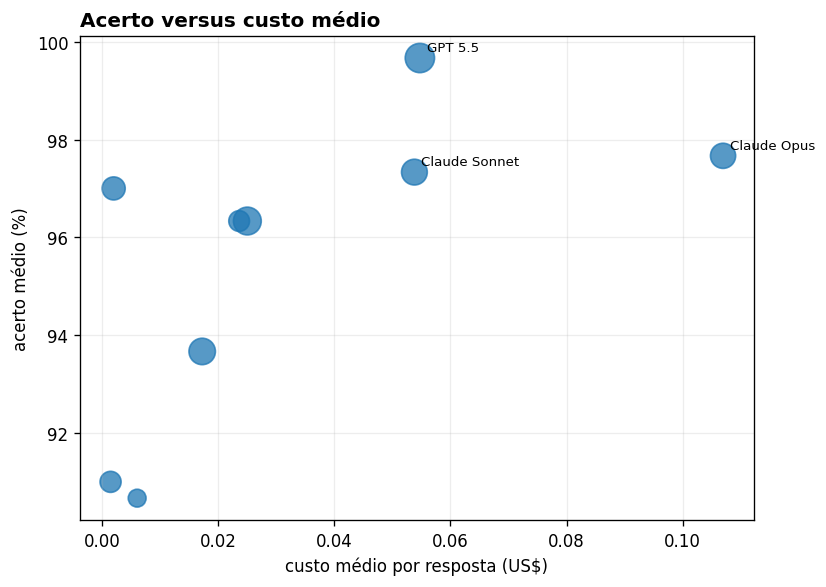

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(m['custo'], m['acerto']*100, s=np.sqrt(m['tempo_tipico'])*70, alpha=0.75)
ax.set_title('Acerto versus custo médio', loc='left')
ax.set_xlabel('custo médio por resposta (US$)')
ax.set_ylabel('acerto médio (%)')
for nome, row in m.sort_values('acerto', ascending=False).head(3).iterrows():
    ax.annotate(nome, (row['custo'], row['acerto']*100), xytext=(4, 4), textcoords='offset points', fontsize=8)
plt.tight_layout()
plt.show()

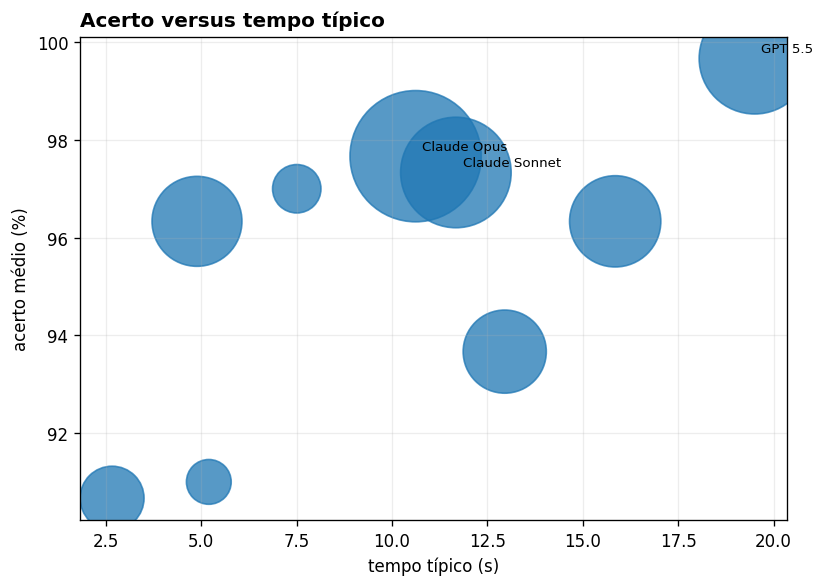

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(m['tempo_tipico'], m['acerto']*100, s=np.sqrt(m['custo']*100000)*60, alpha=0.75)
ax.set_title('Acerto versus tempo típico', loc='left')
ax.set_xlabel('tempo típico (s)')
ax.set_ylabel('acerto médio (%)')
for nome, row in m.sort_values('acerto', ascending=False).head(3).iterrows():
    ax.annotate(nome, (row['tempo_tipico'], row['acerto']*100), xytext=(4, 4), textcoords='offset points', fontsize=8)
plt.tight_layout()
plt.show()

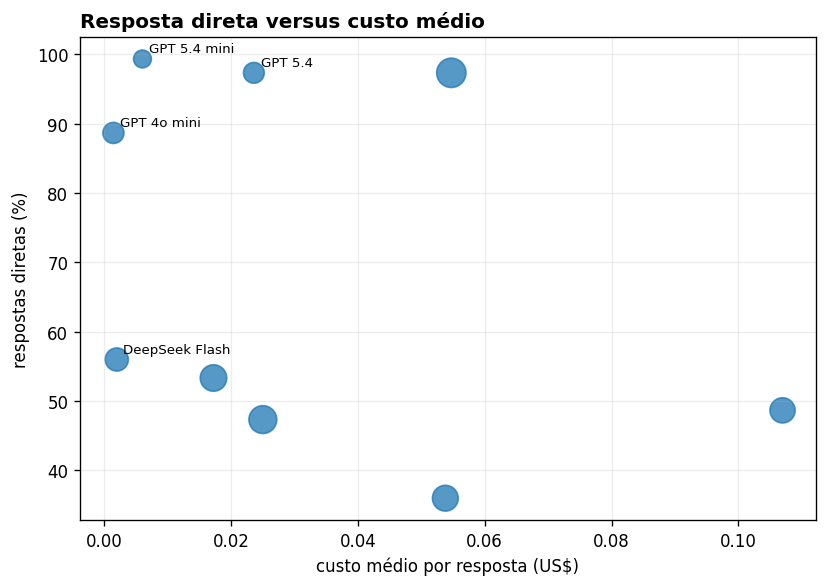

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(m['custo'], m['direta']*100, s=np.sqrt(m['tempo_tipico'])*70, alpha=0.75)
ax.set_title('Resposta direta versus custo médio', loc='left')
ax.set_xlabel('custo médio por resposta (US$)')
ax.set_ylabel('respostas diretas (%)')
for nome, row in pd.concat([m.nlargest(2,'direta'), m.nsmallest(2,'custo')]).drop_duplicates().iterrows():
    ax.annotate(nome, (row['custo'], row['direta']*100), xytext=(4, 4), textcoords='offset points', fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
# Modelos eficientes: nenhum outro modelo é melhor ou igual em acerto e, ao mesmo tempo, menor ou igual em custo e tempo.
def eficientes_pareto(tab, max_cols, min_cols):
    vals = tab.copy()
    keep = []
    for idx, row in vals.iterrows():
        dominado = False
        for jdx, other in vals.iterrows():
            if idx == jdx:
                continue
            melhor_ou_igual_max = all(other[c] >= row[c] for c in max_cols)
            melhor_ou_igual_min = all(other[c] <= row[c] for c in min_cols)
            estritamente_melhor = any(other[c] > row[c] for c in max_cols) or any(other[c] < row[c] for c in min_cols)
            if melhor_ou_igual_max and melhor_ou_igual_min and estritamente_melhor:
                dominado = True
                break
        keep.append(not dominado)
    return pd.Series(keep, index=tab.index)

m['melhor_equilibrio'] = eficientes_pareto(m, max_cols=['acerto','direta'], min_cols=['custo','tempo_tipico'])
display(Markdown('### Modelos na fronteira de melhor equilíbrio'))
tabela_formatada(m[m['melhor_equilibrio']].sort_values(['acerto','direta'], ascending=False).reset_index(),
                 percent_cols=['acerto','correta','direta'], money_cols=['custo'], round_cols=['tempo_tipico','tempo_alto','chamadas','tokens_saida'], n=20)

### Modelos na fronteira de melhor equilíbrio

,modelo_legivel,n,acerto,correta,direta,custo,tempo_tipico,tempo_alto,chamadas,tokens_saida,melhor_equilibrio
0,GPT 5.5,150,99.7%,99.3%,97.3%,US$ 0.05473,19.505,43.010,2.347,263.080,True
1,Claude Opus,150,97.7%,95.3%,48.7%,US$ 0.10696,10.620,23.900,2.240,595.180,True
2,Claude Sonnet,150,97.3%,94.7%,36.0%,US$ 0.05379,11.675,21.090,2.333,567.307,True
3,DeepSeek Flash,150,97.0%,94.0%,56.0%,US$ 0.00198,7.505,17.645,2.407,429.007,True
4,GPT 5.4,150,96.3%,94.0%,97.3%,US$ 0.02360,4.890,10.614,2.327,178.553,True
5,GPT 4o mini,150,91.0%,84.7%,88.7%,US$ 0.00145,5.200,9.734,2.247,182.747,True
6,GPT 5.4 mini,150,90.7%,84.0%,99.3%,US$ 0.00603,2.665,5.136,2.353,172.927,True


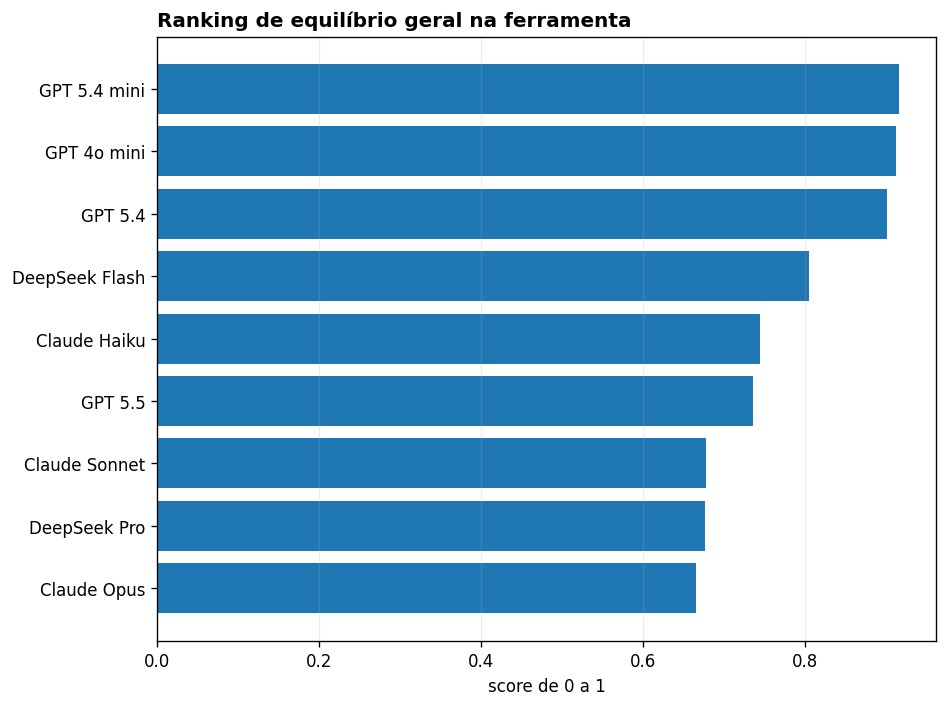

,modelo_legivel,n,acerto,correta,direta,custo,tempo_tipico,tempo_alto,chamadas,tokens_saida,melhor_equilibrio,acerto_norm,direta_norm,custo_norm,tempo_tipico_norm,chamadas_norm,score_equilibrio
0,GPT 5.4 mini,150,90.7%,84.0%,99.3%,US$ 0.00603,2.665,5.136,2.353,172.927,True,0.906667,0.993333,0.956601,1.000000,0.32,91.6%
1,GPT 4o mini,150,91.0%,84.7%,88.7%,US$ 0.00145,5.200,9.734,2.247,182.747,True,0.910000,0.886667,1.000000,0.849466,0.96,91.2%
2,GPT 5.4,150,96.3%,94.0%,97.3%,US$ 0.02360,4.890,10.614,2.327,178.553,True,0.963333,0.973333,0.790085,0.867874,0.48,90.1%
3,DeepSeek Flash,150,97.0%,94.0%,56.0%,US$ 0.00198,7.505,17.645,2.407,429.007,True,0.970000,0.560000,0.994951,0.712589,0.00,80.5%
4,Claude Haiku,150,93.7%,88.0%,53.3%,US$ 0.01723,12.955,60.528,2.307,460.373,False,0.936667,0.533333,0.850427,0.388955,0.60,74.4%
5,GPT 5.5,150,99.7%,99.3%,97.3%,US$ 0.05473,19.505,43.010,2.347,263.080,True,0.996667,0.973333,0.495000,0.000000,0.36,73.5%
6,Claude Sonnet,150,97.3%,94.7%,36.0%,US$ 0.05379,11.675,21.090,2.333,567.307,True,0.973333,0.360000,0.503926,0.464964,0.44,67.7%
7,DeepSeek Pro,150,96.3%,92.7%,47.3%,US$ 0.02501,15.850,34.058,2.407,475.747,False,0.963333,0.473333,0.776691,0.217043,0.00,67.7%
8,Claude Opus,150,97.7%,95.3%,48.7%,US$ 0.10696,10.620,23.900,2.240,595.180,True,0.976667,0.486667,0.000000,0.527613,1.00,66.6%


In [7]:
# Score de equilíbrio com pesos explícitos. Ajuste os pesos se o TCC quiser priorizar outra dimensão.
pesos = {'acerto': 0.45, 'direta': 0.20, 'custo': 0.15, 'tempo_tipico': 0.15, 'chamadas': 0.05}
rank = m.copy()
rank['acerto_norm'] = rank['acerto']
rank['direta_norm'] = rank['direta']
for col in ['custo','tempo_tipico','chamadas']:
    mn, mx = rank[col].min(), rank[col].max()
    rank[col + '_norm'] = 1 - (rank[col] - mn) / (mx - mn) if mx > mn else 1
rank['score_equilibrio'] = (
    pesos['acerto'] * rank['acerto_norm'] +
    pesos['direta'] * rank['direta_norm'] +
    pesos['custo'] * rank['custo_norm'] +
    pesos['tempo_tipico'] * rank['tempo_tipico_norm'] +
    pesos['chamadas'] * rank['chamadas_norm']
)
rank = rank.sort_values('score_equilibrio', ascending=False)
barh_series(rank['score_equilibrio'].sort_values(), 'Ranking de equilíbrio geral na ferramenta', 'score de 0 a 1', figsize=(8, 6))
tabela_formatada(rank.reset_index(), percent_cols=['score_equilibrio','acerto','correta','direta'], money_cols=['custo'], round_cols=['tempo_tipico','tempo_alto','chamadas','tokens_saida'], n=20)

In [8]:
# Sensibilidade: três cenários de decisão.
cenarios = {
    'prioriza_acerto': {'acerto':0.65, 'direta':0.15, 'custo':0.08, 'tempo_tipico':0.08, 'chamadas':0.04},
    'prioriza_eficiencia': {'acerto':0.30, 'direta':0.15, 'custo':0.25, 'tempo_tipico':0.25, 'chamadas':0.05},
    'equilibrado': {'acerto':0.45, 'direta':0.20, 'custo':0.15, 'tempo_tipico':0.15, 'chamadas':0.05},
}
sens = []
for nome, p in cenarios.items():
    tmp = m.copy()
    tmp['acerto_norm'] = tmp['acerto']; tmp['direta_norm'] = tmp['direta']
    for col in ['custo','tempo_tipico','chamadas']:
        mn, mx = tmp[col].min(), tmp[col].max()
        tmp[col+'_norm'] = 1 - (tmp[col]-mn)/(mx-mn) if mx > mn else 1
    tmp['score'] = sum(p[k] * tmp[k + '_norm'] if k in ['custo','tempo_tipico','chamadas'] else p[k] * tmp[k] for k in p)
    top = tmp.sort_values('score', ascending=False).head(5).reset_index()[['modelo_legivel','score']]
    top['cenario'] = nome
    top['posicao'] = np.arange(1, len(top)+1)
    sens.append(top)
sens = pd.concat(sens, ignore_index=True)
display(sens[['cenario','posicao','modelo_legivel','score']].round(3))

,cenario,posicao,modelo_legivel,score
0,prioriza_acerto,1,GPT 5.4,0.924
1,prioriza_acerto,2,GPT 4o mini,0.911
2,prioriza_acerto,3,GPT 5.4 mini,0.908
3,prioriza_acerto,4,DeepSeek Flash,0.851
4,prioriza_acerto,5,GPT 5.5,0.848
5,prioriza_eficiencia,1,GPT 5.4 mini,0.926
6,prioriza_eficiencia,2,GPT 4o mini,0.916
7,prioriza_eficiencia,3,GPT 5.4,0.873
8,prioriza_eficiencia,4,DeepSeek Flash,0.802
9,prioriza_eficiencia,5,Claude Haiku,0.701
